# Configurer environement de travail

In [1]:
!pip install -q monai
!pip install -q SimpleITK
!pip install -q torchio
!pip install git+https://github.com/facebookresearch/segment-anything.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 4.1 MB/s eta 0:00:00
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-zoybsrth
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-zoybsrth
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [2]:
!pip install -q huggingface_hub
!pip install hydra-core omegaconf iopath fvcore --quiet
!pip install -q kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.7 MB/s eta 0:00:00


In [3]:
!git clone https://github.com/bowang-lab/MedSAM2.git
%cd /kaggle/working/MedSAM2
%pip install -e .

fatal: destination path 'MedSAM2' already exists and is not an empty directory.
/kaggle/working/MedSAM2
Obtaining file:///kaggle/working/MedSAM2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for MedSAM2 (pyproject.toml) ... done
  Created wheel for MedSAM2: filename=medsam2-1.0-0.editable-cp312-cp312-linux_x86_64.whl size=10560 sha256=f29f92632638fed44bca99ffa68490d88ebac73a465bdad7c94201c011c5ea58
  Stored in directory: /tmp/pip-ephem-wheel-cache-9ewu2s3n/wheels/0f/90/32/18c63f6c69430be10ea31f3621fd6cfd872d95c8e92e35698c
Successfully built MedSAM2
Note: you may need to restart the kernel to use updated packages.


In [4]:
!mkdir -p checkpoint
!wget -p checkpoints https://huggingface.co/wanglab/MedSAM2/resolve/main/MedSAM2_2411.pt

--2026-06-13 12:50:44--  http://checkpoints/
Resolving checkpoints (checkpoints)... failed: Name or service not known.
wget: unable to resolve host address ‘checkpoints’
--2026-06-13 12:50:44--  https://huggingface.co/wanglab/MedSAM2/resolve/main/MedSAM2_2411.pt
Resolving huggingface.co (huggingface.co)... 13.226.251.20, 13.226.251.66, 13.226.251.112, ...
Connecting to huggingface.co (huggingface.co)|13.226.251.20|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/67ec555237f4f95c13aa9748/a8339a4765ba20d3170ac7574cecd5d8760306181a683528ff61f94170262e4e?user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27MedSAM2_2411.pt%3B+filename%3D%22MedSAM2_2411.pt%22%3B&X-Xet-Cas-Uid=public&Expires=1781358644&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjdlYzU1NTIzN2Y0Zjk1YzEzYWE5NzQ4L2E4MzM5YTQ3NjViYTIwZDMxNzBhYzc1NzRjZWNkNWQ4NzYwMzA2MTgxYTY4MzUyOGZmNjFmOTQ

# Preparation des données

In [5]:
import os
import numpy as np
import torch
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from monai.transforms import Compose, LoadImage, EnsureChannelFirst, ScaleIntensity
import random
import kagglehub

2026-06-13 12:51:08.866922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781355069.073850      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781355069.134560      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781355069.624373      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781355069.624413      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781355069.624416      57 computation_placer.cc:177] computation placer alr

In [6]:
!pip install -q kagglehub
!pip install -q git+https://github.com/kaggle/kagglehub.git --upgrade

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 6.2 MB/s eta 0:00:0000:01


In [7]:
# Download dataset
path = kagglehub.dataset_download("aryashah2k/brain-tumor-segmentation-brats-2019")
print("Dataset downloaded to:", path)

Dataset downloaded to: /kaggle/input/brain-tumor-segmentation-brats-2019


In [8]:
# Dataset structure paths
import os
brats_path = "/kaggle/input/brain-tumor-segmentation-brats-2019/MICCAI_BraTS_2019_Data_Training"  # This is where Kaggle downloads the files
hgg_path = os.path.join(brats_path, "/kaggle/input/brain-tumor-segmentation-brats-2019/MICCAI_BraTS_2019_Data_Training/HGG")
lgg_path = os.path.join(brats_path, "/kaggle/input/brain-tumor-segmentation-brats-2019/MICCAI_BraTS_2019_Data_Training/LGG")

In [9]:
# Verify files
print(f"Number of HGG cases: {len(os.listdir(hgg_path))}")
print(f"Number of LGG cases: {len(os.listdir(lgg_path))}")

Number of HGG cases: 259
Number of LGG cases: 76


# Prtraitement des données de BRATS 2019

| Label | Composante Tumorale | Description Clinique | 
| :--- | :--- | :--- | 
| 0 | Fond (Background) | Tissus sains et liquide céphalorachidien. | 
| 1 | Noyau Necrotique (NCR) | Zone centrale non rehaussée, souvent nécrotique. | 
| 2 | Œdème (ED) | Inflammation et infiltration péri-tumorale. |
| 4 | Tumeur Rehaussée (ET) | Tissu tumoral actif après injection de contraste. |

In [10]:
def preprocess_volume(volume_path, mask_path):
    """Load and preprocess a BRATS volume"""
    volume = sitk.ReadImage(volume_path)
    mask = sitk.ReadImage(mask_path)
    spacing = mask.GetSpacing()
    
    volume_array = sitk.GetArrayFromImage(volume)
    mask_array = sitk.GetArrayFromImage(mask)

    surfaces = np.sum(mask_array > 0, axis=(1, 2))
    massk_ref_id = np.argmax(surfaces)
    
    # Normalize to [0, 255]
    volume_array = (volume_array - volume_array.min()) / (volume_array.max() - volume_array.min()) * 255
    
    return volume_array.astype(np.uint8), mask_array, massk_ref_id, spacing

def compute_volume(mask, spacing):
    n_voxels = (mask > 0).sum()
    sx, sy, sz = spacing
    volume_mm3 = (n_voxels *  sx * sy * sz ) / 1000
    return volume_mm3

def visualize_data(case_path, title):
    """Visualize preprocessed image slices"""

    """Load, normalize, resize, and stack modalities + segmentation"""
    modalities = ['t1', 't1ce', 't2', 'flair']
    channels = []
    label_info = {
        1: "Noyau (NCR/NET)", 
        2: "Oedème (ED)", 
        4: "Rehaussée (ET)"
    }
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))

    
    for i, mod in enumerate(modalities):
        volume_path = os.path.join(case_path, f"{os.path.basename(case_path)}_{mod}.nii")
        mask_path =  seg_path = os.path.join(case_path, f"{os.path.basename(case_path)}_seg.nii")
        img, seg, slide_idx, spacing = preprocess_volume(volume_path, mask_path)
        volume = compute_volume(seg, spacing)
        
        # 1. Afficher les 4 modalités 
        axes[0][i].imshow(img[slide_idx, :, :], cmap='gray')
        axes[0][i].set_title(f"{mod.upper()} (Slide {slide_idx})")
        axes[0][i].axis('off')
    
    # 2. Afficher la segmentation 
    slice_seg = seg[slide_idx]

    # Case 1: Image complète de segmentation (tous les labels ensemble)
    axes[1][0].imshow(slice_seg, cmap='jet')
    axes[1][0].set_title(f"Mask complet - {volume}mm²")
        
    # Case 2, 3, 4: Extraction de chaque label spécifique
    for j, (val, name) in enumerate(label_info.items(), start=1):
        axes[1][j].imshow(slice_seg == val, cmap='gray')
        axes[1][j].set_title(name)
            
    for ax in axes[1]:
        ax.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [11]:
# Exemple de cas path
sample_case_hgg = os.path.join(hgg_path, os.listdir(hgg_path)[0])
sample_case_lgg = os.path.join(lgg_path, os.listdir(lgg_path)[0])
print("Sample case files HGG: ", os.listdir(sample_case_hgg))
print("Sample case files LGG: ",os.listdir(sample_case_lgg))

Sample case files HGG:  ['BraTS19_2013_27_1_seg.nii', 'BraTS19_2013_27_1_t1.nii', 'BraTS19_2013_27_1_t1ce.nii', 'BraTS19_2013_27_1_flair.nii', 'BraTS19_2013_27_1_t2.nii']
Sample case files LGG:  ['BraTS19_TCIA10_632_1_t2.nii', 'BraTS19_TCIA10_632_1_t1.nii', 'BraTS19_TCIA10_632_1_seg.nii', 'BraTS19_TCIA10_632_1_t1ce.nii', 'BraTS19_TCIA10_632_1_flair.nii']


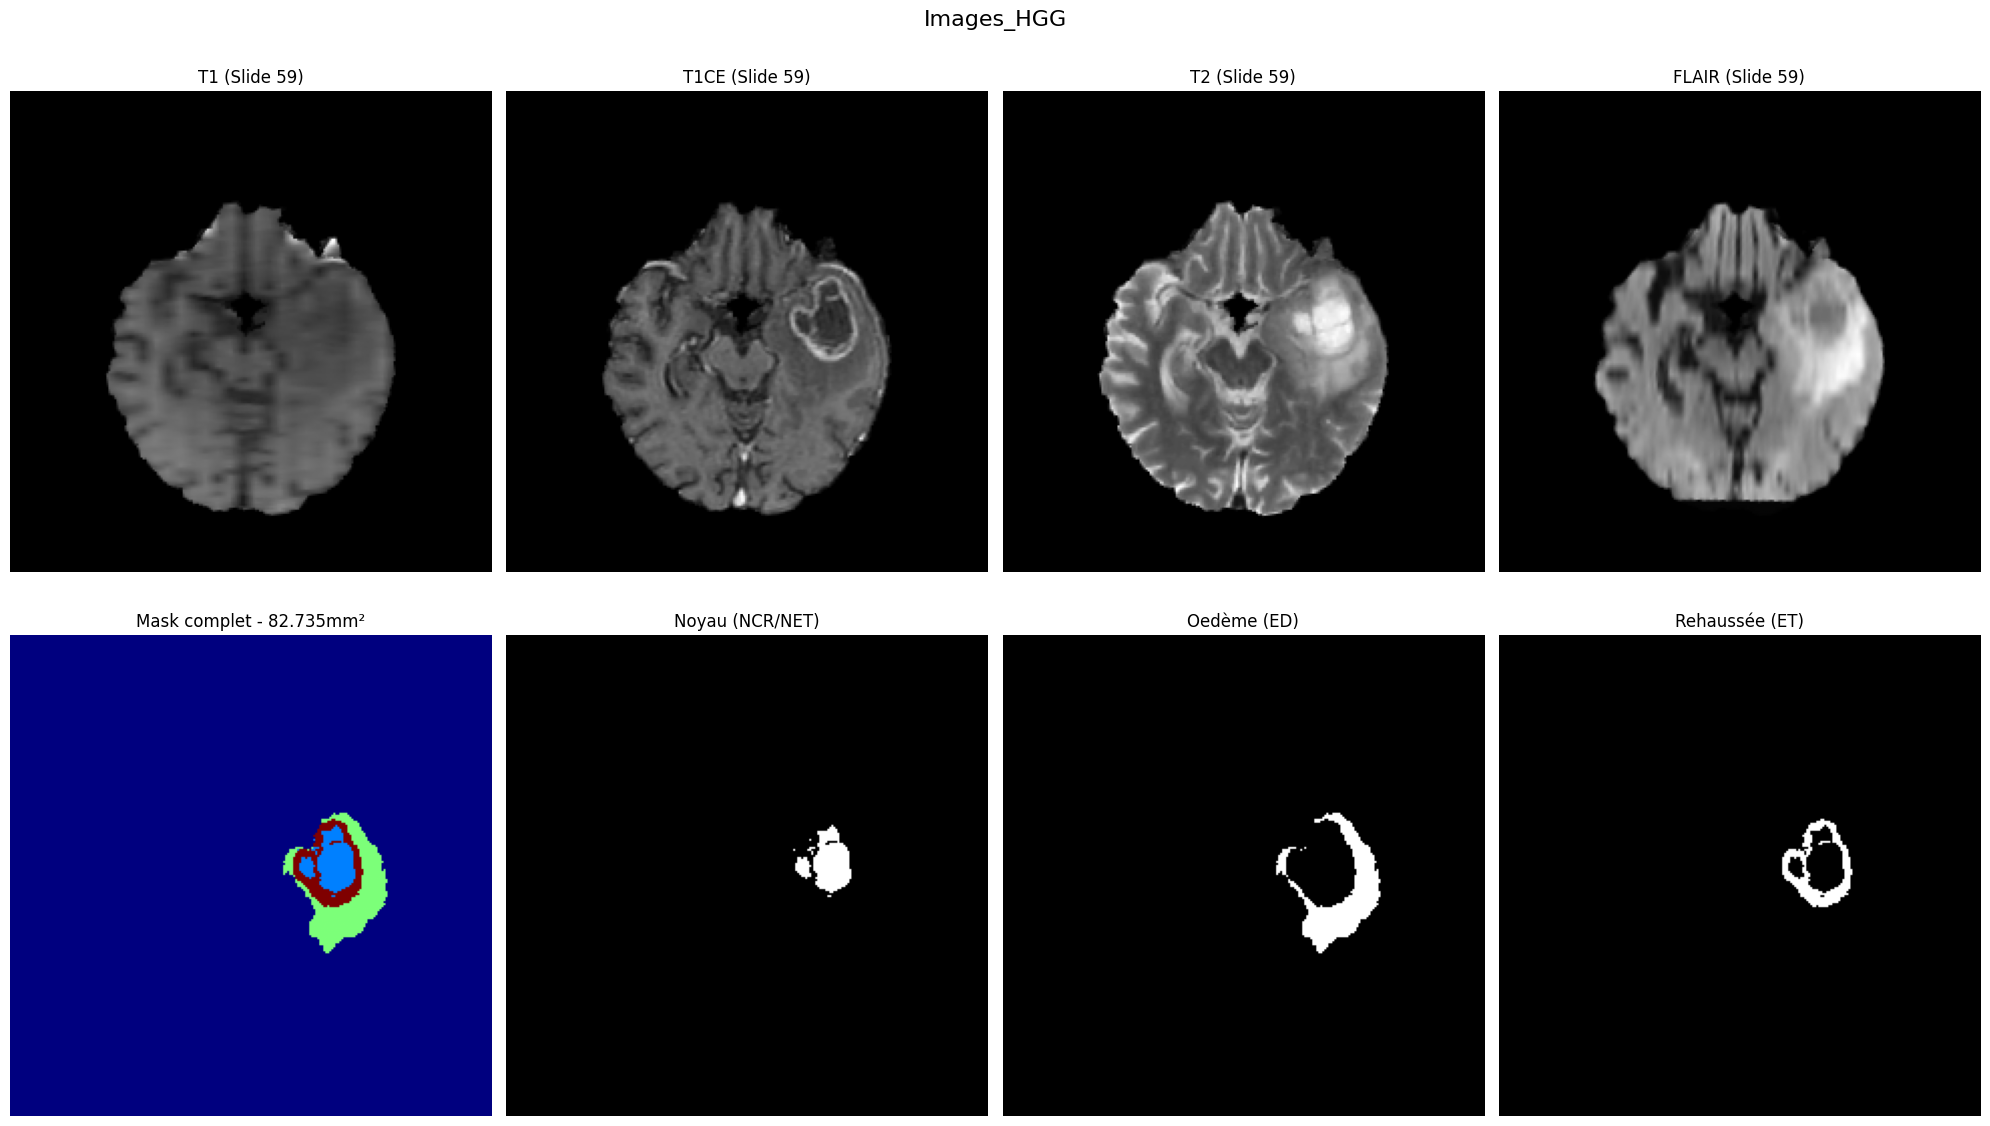

In [12]:
visualize_data(sample_case_hgg,  "Images_HGG")

# Prompt ingenieurie

Pourquoi cette approche est la plus robuste pour BraTS ?
LargestCC : Élimine le bruit environnant, ce qui évite au modèle de s'étendre sur des zones saines qui pourraient avoir une texture similaire (comme les ventricules).

Padding : SAM 2 utilise les pixels autour de l'objet pour comprendre le contraste "Tumeur vs Tissu sain". Une marge de 5 pixels aide énormément.

Point Central : La BBOX définit la zone de recherche, mais le point central confirme au modèle quelle structure est la cible prioritaire à l'intérieur de cette zone.

In [13]:
def get_complete_prompts(mask_ref, max_point, out_point = True):
    # 1. Nettoyage et Box d'origine
    rows, cols = np.where(mask_ref.astype(bool))
    if len(rows) == 0: return None
    
    x_min, x_max = cols.min(), cols.max()
    y_min, y_max = rows.min(), rows.max()
    w, h = x_max - x_min + 1, y_max - y_min + 1
    cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2 
    
    # Dictionnaire des boxes (GT + Déformées)
    boxes = {
        'original_gt': np.array([x_min, y_min, x_max, y_max]),
        'vert_small':  np.array([cx - w*0.35, cy - h*0.55, cx + w*0.35, cy + h*0.55]),
        'vert_medium': np.array([cx - w*0.45, cy - h*0.75, cx + w*0.45, cy + h*0.75]),
        'horiz_small': np.array([cx - w*0.65, cy - h*0.40, cx + w*0.65, cy + h*0.40]),
        'horiz_medium':np.array([cx - w*0.80, cy - h*0.50, cx + w*0.80, cy + h*0.50])
    }
    
    # 2. Point Central (Positif = Label 1)
    point_coords = [[cx, cy]]
    point_labels = [1]

    if out_point:
        # 3. 5 Points Négatifs (Label 0) hors de la tumeur
        bg_rows, bg_cols = np.where(mask_ref == 0)
        #indices = random.sample(range(len(bg_rows)), 5)
        cy, cx = mask_ref.shape[0]//2, mask_ref.shape[1]//2
        dist = (bg_rows - cy)**2 + (bg_cols - cx)**2
        proba = 1 / (dist + 1e-4)
        proba /= proba.sum()
        
        indices = np.random.choice(len(bg_rows), size=5, replace=False, p=None)
        
        for idx in indices:
            point_coords.append([bg_cols[idx], bg_rows[idx]])
            point_labels.append(0)
        
    # Clip des boxes pour l'image 256x256
    for k in boxes: 
        boxes[k] = np.clip(boxes[k], 0, max_point)
        
    return boxes, np.array(point_coords), np.array(point_labels)

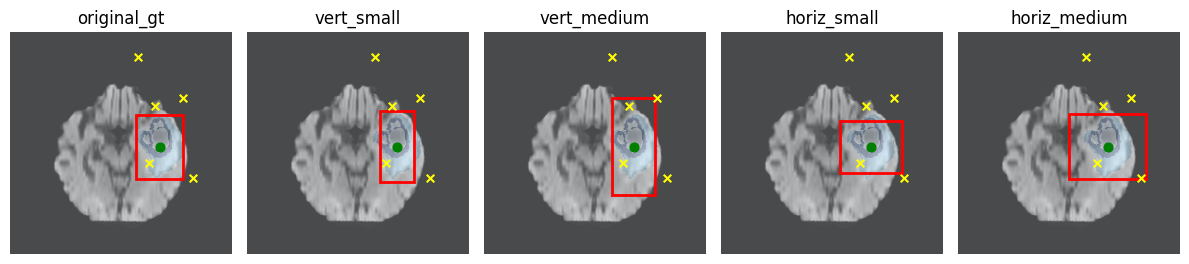

In [14]:
volume_path = os.path.join(sample_case_hgg, f"{os.path.basename(sample_case_hgg)}_flair.nii")
mask_path =  seg_path = os.path.join(sample_case_hgg, f"{os.path.basename(sample_case_hgg)}_seg.nii")
img, seg, slide_idx, _ = preprocess_volume(volume_path, mask_path)

image_slice = img[slide_idx, :, :]
masks = seg[slide_idx, :, :]

# --- CTest sur la generation de prompt
res = get_complete_prompts(masks, 240)
if res:
    boxes, all_points, all_labels = res
    fig, axes = plt.subplots(1, 5, figsize=(12, 6))
    
    for i, (name, box) in enumerate(boxes.items()):
        ax = axes[i]
        ax.imshow(image_slice, cmap='gray')
        
        # Afficher le masque prédit (en bleu transparent)
        ax.imshow(masks, alpha=0.3, cmap='Blues')
        
        # Dessiner la Bounding Box (Rouge)
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        
        # Point central (Vert)
        ax.scatter(all_points[0,0], all_points[0,1], color='green', s=40, label='Centre')
        # Points négatifs (Jaune)
        ax.scatter(all_points[1:,0], all_points[1:,1], color='yellow', marker='x', s=30, label='Négatifs')
        
        ax.set_title(f"{name}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Inference de MedSam2 et evalution

In [15]:
from huggingface_hub import hf_hub_download
from PIL import Image
from glob import glob
from tqdm import tqdm
from collections import OrderedDict
from sam2.build_sam import build_sam2_video_predictor_npz
from skimage import measure
import pandas as pd
import time

In [16]:
# Download the checkpoint
os.makedirs("checkpoints", exist_ok=True)
model_files = [
    "MedSAM2_2411.pt",
    "MedSAM2_MRI_LiverLesion.pt",
    "MedSAM2_latest.pt",
]

print("Downloading MedSAM2 checkpoint...")
for model_file in model_files:
    try:
        hf_hub_download(
            repo_id="wanglab/MedSAM2",
            filename=model_file,
            local_dir="checkpoints",
            local_dir_use_symlinks=False
        )
        print(f"Downloaded (model_file)")
    except Exception as e:
        print(f'Failed to download (model_file): {str(e)}')

path_data = "/kaggle/input/brast-50/BraTS2021_npz_50"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


MedSAM2_2411.pt:   0%|          | 0.00/156M [00:00<?, ?B/s]

Downloaded (model_file)


MedSAM2_MRI_LiverLesion.pt:   0%|          | 0.00/156M [00:00<?, ?B/s]

Downloaded (model_file)


MedSAM2_latest.pt:   0%|          | 0.00/156M [00:00<?, ?B/s]

Downloaded (model_file)


In [17]:
# Load mMedSAM2 model (using the latest version)
checkpoint = ["./checkpoints/MedSAM2_latest.pt", "./checkpoints/MedSAM2_MRI_LiverLesion.pt", "sam2.1_hiera_tiny.pt"]
model_cfg = "configs/sam2.1_hiera_t512.yaml"
predictor = build_sam2_video_predictor_npz(model_cfg, checkpoint[0], verbose = 0).to(device)
predictor.eval()
print("Model charger correctement")

/kaggle/working/MedSAM2/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


Model charger correctement


In [18]:
# Inference fonction
def resize_(array_3d, size = (512, 512)):
    """Resize 3D volume slices to 512x512"""
    resized = np.zeros((array_3d.shape[0], size[0], size[0]), dtype=np.uint8)
    for i in range(array_3d.shape[0]):
        img = Image.fromarray(array_3d[i])
        img = img.resize(size)
        resized[i] = np.array(img)
    return resized
    
def run_inference(predictor, volume_array, center_slice_idx, bbox, labels = None, points = None ):
    """Run MedSAM2 inference on a 3D volume"""
    # Resize volume
    volume_resized = resize_(volume_array)
    
    # Convert to RGB format expected by MedSAM2
    volume_rgb = np.stack([volume_resized]*3, axis=1)  # Shape: (D, 3, H, W)
    volume_rgb = volume_rgb / 255.0
    
    # Normalize with ImageNet stats
    img_mean = np.array([0.485, 0.456, 0.406])[:, None, None]
    img_std = np.array([0.229, 0.224, 0.225])[:, None, None]
    volume_rgb = (volume_rgb - img_mean) / img_std
    
    # Convert to torch tensor
    volume_tensor = torch.from_numpy(volume_rgb).float().to(device)
    
    # Initialize segmentation array
    segs_3D = np.zeros(volume_resized.shape, dtype=np.uint8)
    
    # Run inference
    with torch.no_grad():
        inference_state = predictor.init_state(volume_tensor, 512, 512)
        
        # Forward propagation
        _, _, _ = predictor.add_new_points_or_box(
            inference_state=inference_state,
            frame_idx=center_slice_idx,
            obj_id=1,
            box=bbox,
            points=points,
            labels=labels,
        )
        
        for out_frame_idx, _, out_mask_logits in predictor.propagate_in_video(inference_state):
            segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1
        
        # Backward propagation
        _, _, _ = predictor.add_new_points_or_box(
            inference_state=inference_state,
            frame_idx=center_slice_idx,
            obj_id=1,
            box=bbox
        )
        
        for out_frame_idx, _, out_mask_logits in predictor.propagate_in_video(inference_state, reverse=True):
            segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1
    
    return segs_3D.astype(np.uint8)

In [19]:
def evaluate_segmentation(v_pred, v_gt, spacing):
    """
    Calcule DICE, IOU, Erreur Relative de Volume (RVE)
    Identifie les meilleures et pires coupes.
    """
    # 1. Métriques Globales (Volume 3D)
    intersection = np.sum(v_pred * v_gt)
    union = np.sum(v_pred) + np.sum(v_gt)

    # Mesure la similarité globale. Très sensible à la précision des contours
    dice_global = (2. * intersection) / (union + 1e-6)
    #Mesure la similarité globale. Très sensible à la précision des contours
    iou_global = intersection / (np.sum(v_pred + v_gt > 0) + 1e-6)
    
    # Erreur Relative de Volume (RVE) en %
    # Si votre RVE est positif, MedSAM 2 surestime la tumeur. S'il est négatif, il sous-estime
    vol_pred = np.sum(v_pred.astype(bool)) 
    vol_gt = np.sum(v_gt.astype(bool))
    
    rve = ((vol_pred - vol_gt) / (vol_gt + 1e-6)) * 100


    # 2. Analyse par Slice
    num_slices = v_pred.shape[0]
    dice_per_slice = []
    valid_slices = [] # On ne stocke que les slices où il y a de la tumeur au moins en GT

    for i in range(num_slices):
        s_pred = v_pred[i]
        s_gt = v_gt[i]
        
        if np.sum(s_gt) > 0: # Focus sur les slices avec cible réelle
            inter_s = np.sum(s_pred * s_gt)
            union_s = np.sum(s_pred) + np.sum(s_gt)
            dice_s = (2. * inter_s) / (union_s + 1e-6)
            dice_per_slice.append(dice_s)
            valid_slices.append(i)
        else:
            dice_per_slice.append(None)

    # 3. Extraction des meilleurs et pires scores
    # On filtre les None pour le calcul
    filtered_dice = [d for d in dice_per_slice if d is not None]

    if len(filtered_dice) > 0:
        mean_dice_slices = np.mean(filtered_dice)
        idx_best = valid_slices[np.argmax(filtered_dice)]
        idx_worst = valid_slices[np.argmin(filtered_dice)]
        surface_best = np.sum(v_gt[idx_best]) * spacing[0] * spacing[1]
        surface_worst = np.sum(v_gt[idx_worst]) * spacing[0] * spacing[1]
        best_score = np.max(filtered_dice)
        worst_score = np.min(filtered_dice)
    else:
        mean_dice_slices, idx_best, idx_worst, best_score, worst_score = 0, 0, 0, 0, 0

    return {
        "Global_Dice": dice_global,
        "Global_IOU": iou_global,
        "RVE_percent": rve,
        "Mean_Dice_Slices": mean_dice_slices,
        "Best_Slice_Idx": surface_best,
        "Best_Slice_Dice": best_score,
        "Worst_Slice_Idx": surface_worst,
        "Worst_Slice_Dice": worst_score,
        "all_dice" : [dice_per_slice, valid_slices]
    }

    "MedSAM2_Original": {
        "checkpoint": "./checkpoints/MedSAM2_2411.pt",
        "config":  "configs/sam2.1_hiera_t512.yaml"
    },

    "MedSAM2_Latest": {
        "checkpoint": "./checkpoints/MedSAM2_latest.pt",
        "config":  "configs/sam2.1_hiera_t512.yaml"
    }

In [20]:
# --- 1. Définition des Checkpoints et Configurations ---
checkpoints_to_compare = {
        "MedSAM2_Liver": {
        "checkpoint": "./checkpoints/MedSAM2_MRI_LiverLesion.pt",
        "config":  "configs/sam2.1_hiera_t512.yaml"
    }
}
modalities = ['flair', 't1ce', 't2']

final_results_all_models = []
final_mask_all_models = []
temps_inference = {}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [21]:
random.seed(52)
# ---  Boucle Principale Intégrant la Comparaison des Modèles ---
for model_name, model_info in checkpoints_to_compare.items():
    print(f"\n--- Évaluation du modèle : {model_name} ---")

    
    # Initialisation du prédicteur pour ce modèle
    model_cfg = "configs/sam2.1_hiera_t512.yaml"
    predictor = build_sam2_video_predictor_npz(config_file = model_info["config"], 
                                               ckpt_path = model_info["checkpoint"]).to(device)
    predictor.eval()
    print(f"Model {model_name} charger correctement")
    
    # Boucle sur tes datasets (HGG et LGG)
    datasets = [("LGG", lgg_path), ("HGG", hgg_path)]
    start_time = time.time()
    
    for category, base_path in datasets:
        all_cases = os.listdir(base_path)
        if len(all_cases) > 60: 
            all_cases = random.sample(all_cases, 2)
        
        # Loop for all images
        for case_name in all_cases:
            # Loop for all modalities
            k = 0
            for selected_mod in modalities:
                case_path = os.path.join(base_path, case_name)
                volume_path = os.path.join(case_path, f"{case_name}_{selected_mod}.nii")
                mask_path = os.path.join(case_path, f"{case_name}_seg.nii")
                
                if not os.path.exists(volume_path) or not os.path.exists(mask_path):
                    print(f"Skipping {case_name}: missing NIfTI files.")
                    continue
    
                # 1. Extraction Master Slice & Normalisation
                volume_3d, grouth_truth_mask, slide_idx_ref, spacing = preprocess_volume(volume_path, mask_path)  
                gt_binary = np.isin(grouth_truth_mask, [1, 2, 4]).astype(np.uint8)
                grouth_truth_mask = resize_(gt_binary, (512, 512))
                volume_mm3 = compute_volume(grouth_truth_mask, spacing)
                
                # 2. Génération des prompts sur la master slice
                res_prompts = get_complete_prompts(grouth_truth_mask[slide_idx_ref], 512, out_point = False)
                if not res_prompts: 
                    print(f"Skipping {case_name}: No tumor found on master slice.")
                    continue
                
                boxes, all_points, all_labels = res_prompts
                # 3. Test de chaque type de Box
                for box_name, box_coords in boxes.items():
                    # Inférence sur la master slice (puisque tu as 'image_2d')
                    predicted_mask = run_inference(predictor, volume_3d, slide_idx_ref, box_coords, 
                                                      labels = all_labels, points = all_points)
                    volume_mm3_predict = compute_volume(predicted_mask, spacing)
                    
                    
                    # Evaluation models
                    grouth_truth_mask = resize_(grouth_truth_mask, (240, 240))
                    predicted_mask = resize_(predicted_mask, (240, 240))
                    stats = evaluate_segmentation(predicted_mask, grouth_truth_mask, spacing)
    
                    # save images mask
                    if k < 30:
                        final_mask_all_models.append({"Model": model_name,
                            "Catégorie": category,
                            "Case_ID": case_name,
                            "volume_tumeur": volume_mm3,
                            "Modalité": selected_mod,
                            "TypeBox": box_name,
                            "predict_mask" : predicted_mask,
                            "truth_mask" : grouth_truth_mask,
                            "image" : volume_3d
                        })
                    k += 1
        
                    # Save statistical data
                    final_results_all_models.append({
                        "Model": model_name,
                        "Catégorie": category,
                        "Case_ID": case_name,
                        "volume_tumeur": volume_mm3,
                        "volume_tumeur_predict": volume_mm3_predict,
                        "Modalité": selected_mod,
                        "TypeBox": box_name,
                        "Dice_Master": round(stats["Global_Dice"], 4),
                        "IOU_Master": round(stats["Global_IOU"], 4),
                        "RVE_Master_Percent": round(stats["RVE_percent"], 2),
                        "Mean_Dice_Vol": stats["Mean_Dice_Slices"],
                        "Best_Surface": stats["Best_Slice_Idx"], 
                        "Best_Slice_Dice": stats["Best_Slice_Dice"], 
                        "Worst_Surface": stats["Worst_Slice_Idx"], 
                        "Worst_Slice_Dice": stats["Worst_Slice_Dice"]  
                    })
                    print(f"Pire coupe: Index {stats['Worst_Slice_Idx']} model: {model_name} (Score: {stats['Worst_Slice_Dice']:.4f})")
                    print(f"Best coupe: Index {stats['Best_Slice_Idx']} (Score: {stats['Best_Slice_Dice']:.4f})")
        temps_inference[model_name] = time.time() - start_time

# Création du DataFrame final
df_res_all_models = pd.DataFrame(final_results_all_models)
os.makedirs("/kaggle/working/results", exist_ok=True)
df_res_all_models.to_csv(f"/kaggle/working/results/resultats_complets_lesion.csv", index=False)


--- Évaluation du modèle : MedSAM2_Liver ---
Model MedSAM2_Liver charger correctement


/kaggle/working/MedSAM2/sam2/sam2_video_predictor_npz.py:965: UserWarning: /kaggle/working/MedSAM2/sam2/_C.so: undefined symbol: _ZNK3c1010TensorImpl15incref_pyobjectEv

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 53/53 [00:02<00:00, 18.45it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py:120: UserWarning: You are adding a box after tracking starts. SAM 2 may not always be able to incorporate a box prompt for *refinement*. If you intend to use box prompt as an *initial* input before tracking, please call 'reset_state' on the inference state to restart from scratch.
  return func(*args, **kwargs)
propagate in video: 100%|██████████| 10

Pire coupe: Index 1.0 model: MedSAM2_Liver (Score: 0.0000)
Best coupe: Index 3492.0 (Score: 0.9689)


propagate in video: 100%|██████████| 103/103 [00:05<00:00, 18.60it/s]


Pire coupe: Index 1.0 model: MedSAM2_Liver (Score: 0.0000)
Best coupe: Index 3492.0 (Score: 0.9602)


...

Pire coupe: Index 14.0 model: MedSAM2_Liver (Score: 0.0776)
Best coupe: Index 4410.0 (Score: 0.9671)


propagate in video: 100%|██████████| 79/79 [00:04<00:00, 16.55it/s]


Pire coupe: Index 41.0 model: MedSAM2_Liver (Score: 0.0000)
Best coupe: Index 4199.0 (Score: 0.9479)


propagate in video: 100%|██████████| 79/79 [00:04<00:00, 16.35it/s]


Pire coupe: Index 14.0 model: MedSAM2_Liver (Score: 0.0221)
Best coupe: Index 3610.0 (Score: 0.9568)


# Analyse des resultats

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal

# 1. Préparation du DataFrame
df = pd.DataFrame(final_results_all_models)

# 2. Création de la figure (2 colonnes pour comparer)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ANALYSE A : LGG vs HGG (Tumeurs) ---
# Calcul statistique LGG vs HGG
lgg = df[df['Catégorie'] == 'LGG']['Dice_Master']
hgg = df[df['Catégorie'] == 'HGG']['Dice_Master']
u_stat, p_tumeur = mannwhitneyu(lgg, hgg)

# --- ANALYSE B : MODALITÉS IRM ---
# Calcul statistique global pour les 4 modalités
mod_groups = [group['Dice_Master'].values for name, group in df.groupby('Modalité')]
h_stat, p_modalite = kruskal(*mod_groups)

# 3. Affichage des conclusions dans la console
print("--- RÉSULTATS STATISTIQUES ---")
print(f"Différence LGG vs HGG : p-value = {p_tumeur:.4f}")
if p_tumeur < 0.05:
    print("=> Résultat SIGNIFICATIF : Le type de tumeur impacte la performance.")
else:
    print("=> Pas de différence significative entre LGG et HGG.")

print(f"\nDifférence entre Modalités : p-value = {p_modalite:.4f}")
if p_modalite < 0.05:
    # 2. Si significatif, on cherche quelle modalité est la meilleure
    print("\nDifférence significative détectée. Analyse Post-hoc (Dunn) :")
    posthoc = sp.posthoc_dunn(df, val_col='Dice_Master', group_col='Modalité', p_adjust='holm')
    print(posthoc)
    
    # Visualisation de la matrice de p-values
    plt.figure(figsize=(8, 6))
    sns.heatmap(posthoc, annot=True, cmap='coolwarm', vmin=0, vmax=0.05)
    plt.title("Matrice de significativité entre modalités (p-values)")
    plt.show()
else:
    print("=> Aucune modalité ne se détache vraiment statistiquement.")

plt.tight_layout()
plt.show()

# --- VISUALISATION ---

plt.figure(figsize=(15, 6))

# Graphique 1 : Boxplot LGG vs HGG
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Catégorie', y='Dice_Master', palette='Set2')
sns.stripplot(data=df, x='Catégorie', y='Dice_Master', color='black', alpha=0.3)
plt.title('Comparaison de performance : LGG vs HGG')
plt.ylabel('Score Dice (Master)')

# Graphique 2 : Influence des Modalités
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Modalité', y='Dice_Master', hue='Catégorie', capsize=.1)
plt.title('Performance par Modalité et Catégorie')
plt.ylabel('Score Dice Moyen')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
def visualize_comparison(data_dict, slice_idx=None):
    """
    Visualise les masques réel, prédit et la superposition sur l'image.
    data_dict: un élément de votre liste final_mask_all_models
    """
    # 1. Extraction des données
    img_3d = data_dict['image']
    pred_3d = data_dict['predict_mask']
    gt_3d = data_dict['truth_mask']
    
    # 2. Choix de la slice à afficher
    # Si slice_idx n'est pas fourni, on prend la coupe centrale du volume
    if slice_idx is None:
        slice_idx = img_3d.shape[0] // 2
        
    img_2d = img_3d[slice_idx]
    pred_2d = pred_3d[slice_idx]
    gt_2d = gt_3d[slice_idx]

    # 3. Création de la figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Colonne 1 : Ground Truth (Réel)
    axes[0].imshow(img_2d, cmap='gray')
    axes[0].imshow(gt_2d, cmap='Greens', alpha=0.5) # Masque réel en Vert
    axes[0].set_title(f"Vérité Terrain (GT)\nSlice: {slice_idx}")
    axes[0].axis('off')

    # Colonne 2 : Prediction
    axes[1].imshow(img_2d, cmap='gray')
    axes[1].imshow(pred_2d, cmap='Oranges', alpha=0.5) # Prédiction en Orange
    axes[1].set_title(f"Prédiction : {data_dict['Model']}\nBox: {data_dict['TypeBox']}")
    axes[1].axis('off')

    # Colonne 3 : Superposition (Image + GT + Pred)
    axes[2].imshow(img_2d, cmap='gray')
    # On affiche le GT en contour vert et la Pred en rouge transparent
    axes[2].contour(gt_2d, colors='lime', linewidths=1) 
    axes[2].imshow(pred_2d, cmap='Reds', alpha=0.3)
    axes[2].set_title(f"Superposition\nVert=Réel, Rouge=Pred")
    axes[2].axis('off')

    plt.suptitle(f"Cas: {data_dict['Case_ID']} ({data_dict['Catégorie']}) - Volume: {data_dict['volume_tumeur']:.2f} mm³", fontsize=15)
    plt.tight_layout()
    plt.show()

# --- EXEMPLE D'UTILISATION ---
# visualize_comparison(final_mask_all_models[0])

In [ ]:
# Affichage synthétique pour ta présentation
presentation_table = df_res_all_models.groupby(['Catégorie', 'TypeBox']).agg({
    'Dice_Master': 'mean',
    'IOU_Master': 'mean',
    'Mean_Dice_Vol': 'mean',
    'RVE_Master_Percent': 'mean'
}).reset_index()

print("Tableau de Présentation des Performances MedSAM2 :")
print(presentation_table)

# Sauvegarde pour ton rapport
df_res_all_models.to_csv("resultats_complets_medsam2.csv", index=False)

In [ ]:
from scipy.stats import mannwhitneyu

hgg_scores = df_res_all_models[df_res_all_models['Catégorie'] == 'HGG']['Mean_Dice_Vol']
lgg_scores = df_res_all_models[df_res_all_models['Catégorie'] == 'LGG']['Mean_Dice_Vol']

stat, p = mannwhitneyu(hgg_scores, lgg_scores)
print(f"Comparaison HGG vs LGG - p-value: {p:.5f}")

if p < 0.05:
    print("La différence de performance est statistiquement significative.")
else:
    print("Pas de différence significative trouvée.")

In [ ]:
import seaborn as sns
def plot_model_comparison_violin(df, score_column='Dice_Master', title="Comparaison des Modèles SAM 2"):
    plt.figure(figsize=(12, 7))
    sns.violinplot(x='Model', y=score_column, hue='Catégorie', data=df, palette='viridis', split=True, inner='quartile')
    plt.title(title)
    plt.ylabel(f"Score {score_column}")
    plt.xlabel("Modèle SAM 2")
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Utilisation
plot_model_comparison_violin(df_res_all_models, score_column='Dice_Master', 
                             title="DICE sur Master Slice par Modèle et Catégorie")

In [ ]:
# Trouver la slide avec la plus grande surface et calculer le volumes
# Faire inference sur cette slide la (box (min et max du mask) et 5 point radomms pour signaeler nos signal)
# Utiliser comme detection objects des 5 forme de box different
# Pour chaque box calculer le dice et IOU  et volume pour (HGG et LGG)
# Dice (volume(slide_prin), type (HGG or LGG), Encord, Dice_mean, Iou, Volume, pire_slide, meilleur_slide) => Poids 1
# Dice (volume(slide_prin), type (HGG or LGG), Encord, Dice_mean, Iou, Volume, slide, meilleur_slide) => Poids 2

# Tester medsam images justes sur les slide (pire et mauvais pour voir si le resultat s'ameliore)

| Label segementation | Modalité Prioritaire | Justification Clinique | 
|  :--- | :--- | :--- | 
| Tumeur Rehaussée (ET - (mask == 4)) | T1ce | Rupture de la barrière hémato-encéphalique [9]. | 
| Œdème (ED -  (mask == 4)) | FLAIR | Hypersignal lié à l'eau interstitielle [10]. | 
| Noyau (NCR/NET -  (mask == 4)) | T1 / T1ce | Hyposignal associé à la nécrose tissulaire [11]. |

## Notes
Points Négatifs : Les IRM de cerveau ont beaucoup de structures symétriques. Si le modèle déborde sur l'autre hémisphère, placez des points négatifs (labels 0) pour "pousser" le masque à rester dans la zone tumorale.

Dans le cadre de votre étude sur les tumeurs cérébrales, voici l'impact de ces opérations :OpérationImpact sur BraTSRisqueIsland RemovalSupprime les faux positifs dans le reste du cerveau.Peut supprimer de petites métastases réelles si le seuil est trop haut.Hole FillingGarantit que le "Noyau Tumoral" est plein.Peut masquer une zone de nécrose réelle si elle n'était pas censée être segmentée.SmoothingDonne des contours plus naturels pour la radiologie.Peut réduire la précision du contour sur des tumeurs très infiltrantes.